# Analyse results from Pypsa-Earth
This notebook reads the latest optimization described in the config.yaml file and makes plots and summaries of the results.

Sources: 
- Plot capacity - map view: https://github.com/pypsa-meets-earth/documentation/blob/main/notebooks/viz/regional_transm_system_viz.ipynb
- Analyse energy potential: https://github.com/pypsa-meets-earth/documentation/blob/main/notebooks/build_renewable_profiles.ipynb
- Analyse energy generation: https://pypsa.readthedocs.io/en/latest/examples/statistics.html

Some files are needed:
* PyPSA network file (e.g. "elec.nc" contains a lot of details and looks perfect)
* a country shape file (may be found in "resources/shapes/country_shapes.geojson")
* a renewable profile file (may be found in "resources/renewable_profiles/....nc)

## Import packages

In [89]:
import yaml
import pypsa
import warnings
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np
import pandas as pd
from pathlib import Path
import seaborn as sns
from datetime import datetime
from cartopy import crs as ccrs
from pypsa.plot import add_legend_circles, add_legend_lines, add_legend_patches
import os
import xarray as xr
import cartopy

In [90]:
# change current directory to parent folder
import os
import sys

if not os.path.isdir("pypsa-earth"):
    os.chdir("../..")
sys.path.append(os.getcwd()+"/pypsa-earth/scripts")

## Path settings
This section reads the config parameters from your config.yaml file and automatically reads the output of the optimization with those settings

In [91]:
PARENT = os.path.realpath("/home/vse23/Projects/pypsa-earth/") + "/"
config = yaml.safe_load(open(PARENT + "config_NZ.yaml")) #VS "config.yaml"

# Read config.yaml settings:
name = config["run"]["name"]
simpl = config["scenario"]["simpl"]
clusters = config["scenario"]["clusters"]
ll = config["scenario"]["ll"]
opts = config["scenario"]["opts"]

# Ensure elements are strings and properly joined
simpl_str = "_".join(map(str, simpl))
clusters_str = "_".join(map(str, clusters))
ll_str = "_".join(map(str, ll))
opts_str = "_".join(map(str, opts))

nc_file_name = f"elec_s{simpl_str}_{clusters_str}_ec_l{ll_str}_{opts_str}.nc"
scenario_name = name 
scenario_subpath = scenario_name + "/" if scenario_name else ""

# Network file
#results_path = PARENT + f"pypsa-earth/results/networks/elec_s_6_ec_lcopt_Co2L-4H.nc"
#network_path = PARENT + f"pypsa-earth/networks/elec.nc"
results_path = PARENT + f"results/NZ-DryYear2012/networks/elec_s_16_ec_lcopt_Co2L0.40-1h.nc"
network_path = PARENT + f"networks/NZ-DryYear2012/elec.nc"
# Country shape file
regions_onshore_path = PARENT + f"resources/NZ-DryYear2012/shapes/country_shapes.geojson"
# Renewable profile file
solar_path = PARENT + f"resources/NZ-DryYear2012/renewable_profiles/profile_solar.nc"
onwind_path = PARENT + f"resources/NZ-DryYear2012/renewable_profiles/profile_onwind.nc"

## Energy system analysis setup - power and energy generation

In [92]:
warnings.simplefilter(action='ignore', category=FutureWarning)
n = pypsa.Network(results_path)
regions_onshore = gpd.read_file(regions_onshore_path)
country_coordinates = regions_onshore.total_bounds[[0, 2, 1, 3]]
warnings.simplefilter(action='default', category=FutureWarning)

INFO:pypsa.io:Imported network elec_s_16_ec_lcopt_Co2L0.40-1h.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


## Data import check

Plot of the region of interest

Text(0.5, 1.0, 'NZ')

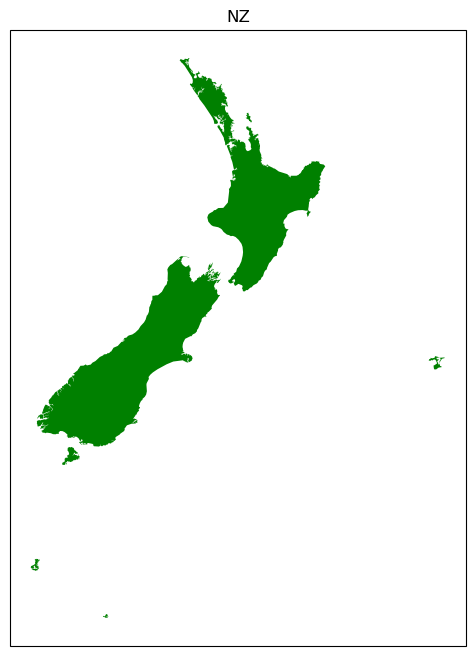

In [93]:
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": ccrs.EqualEarth(n.buses.x.mean())})
with plt.rc_context({"patch.linewidth": 0.}):
    regions_onshore.plot(
    ax=ax,
    facecolor="green",
    edgecolor="white",
    aspect="equal",
    transform=ccrs.PlateCarree(),
    linewidth=0,
    )
ax.set_title(", ".join(regions_onshore.name.values))

List number of components by type

In [94]:
for c in n.iterate_components(list(n.components.keys())[2:]):
    print("Component '{}' has {} entries".format(c.name,len(c.df)))

Component 'Bus' has 32 entries
Component 'Carrier' has 19 entries
Component 'GlobalConstraint' has 1 entries
Component 'Line' has 18 entries
Component 'LineType' has 34 entries
Component 'TransformerType' has 14 entries
Component 'Link' has 33 entries
Component 'Load' has 16 entries
Component 'Generator' has 42 entries
Component 'StorageUnit' has 22 entries
Component 'Store' has 16 entries


List the snapshots of the PyPSA network

In [95]:
print(n.snapshots)
print(f"Time steps: " + str(len(n.snapshots)))

DatetimeIndex(['2012-01-01 00:00:00', '2012-01-01 01:00:00',
               '2012-01-01 02:00:00', '2012-01-01 03:00:00',
               '2012-01-01 04:00:00', '2012-01-01 05:00:00',
               '2012-01-01 06:00:00', '2012-01-01 07:00:00',
               '2012-01-01 08:00:00', '2012-01-01 09:00:00',
               ...
               '2012-12-30 14:00:00', '2012-12-30 15:00:00',
               '2012-12-30 16:00:00', '2012-12-30 17:00:00',
               '2012-12-30 18:00:00', '2012-12-30 19:00:00',
               '2012-12-30 20:00:00', '2012-12-30 21:00:00',
               '2012-12-30 22:00:00', '2012-12-30 23:00:00'],
              dtype='datetime64[ns]', name='snapshot', length=8760, freq=None)
Time steps: 8760


## Analyse energy system

Analyse the current capacity of the energy system - map view

/home/vse23/anaconda3/envs/pypsa-earth/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


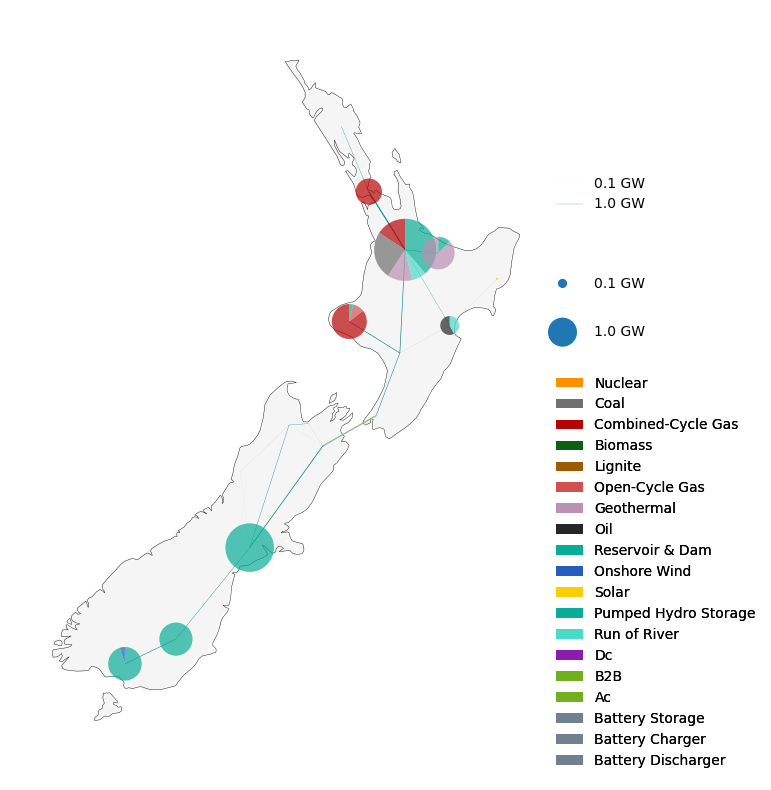

In [96]:
# Scale settings
bus_scale = 6e3
line_scale = 6e3

# Legend settings
bus_sizes = [100, 1000]  # in MW
line_sizes = [100, 1000]  # in MW

# Fixed NZ extent: a tight crop around the country to avoid showing the whole planet
nz_extent = [166.0, 179.0, -48.5, -33.5]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": ccrs.EqualEarth(174.0)})

# use only real generation/storage buses and keep the spatial focus on NZ
gen = n.generators[n.generators.carrier != "load"].groupby(["bus", "carrier"]).p_nom.sum()
sto = n.storage_units.groupby(["bus", "carrier"]).p_nom.sum()
buses = pd.concat([gen, sto])

with plt.rc_context({"patch.linewidth": 0.}):
    n.plot(
        bus_sizes=buses / bus_scale,
        bus_alpha=0.7,
        line_widths=n.lines.s_nom_opt / line_scale,
        link_widths=n.links.p_nom_opt / line_scale,
        line_colors="teal",
        ax=ax,
        margin=0.02,
        color_geomap=None,
    )

regions_onshore.plot(
    ax=ax,
    facecolor="whitesmoke",
    edgecolor="white",
    aspect="equal",
    transform=ccrs.PlateCarree(),
    linewidth=0,
)
ax.set_extent(nz_extent, crs=ccrs.PlateCarree())

legend_kwargs = {"loc": "upper left", "frameon": False}
legend_circles_dict = {"bbox_to_anchor": (1, 0.67), "labelspacing": 2.5, **legend_kwargs}

add_legend_circles(
    ax,
    [s / bus_scale for s in bus_sizes],
    [f"{s / 1000} GW" for s in bus_sizes],
    legend_kw=legend_circles_dict,
)
add_legend_lines(
    ax,
    [s / line_scale for s in line_sizes],
    [f"{s / 1000} GW" for s in line_sizes],
    legend_kw={"bbox_to_anchor": (1, 0.8), **legend_kwargs},
)
add_legend_patches(
    ax,
    n.carriers.color,
    n.carriers.nice_name,
    legend_kw={"bbox_to_anchor": (1, 0), **legend_kwargs, "loc": "lower left"},
)
fig.tight_layout()

Analyse the current generation capacity of the energy system - pie chart view

Text(0.5, 1.0, 'Generator Capacity by Carrier')

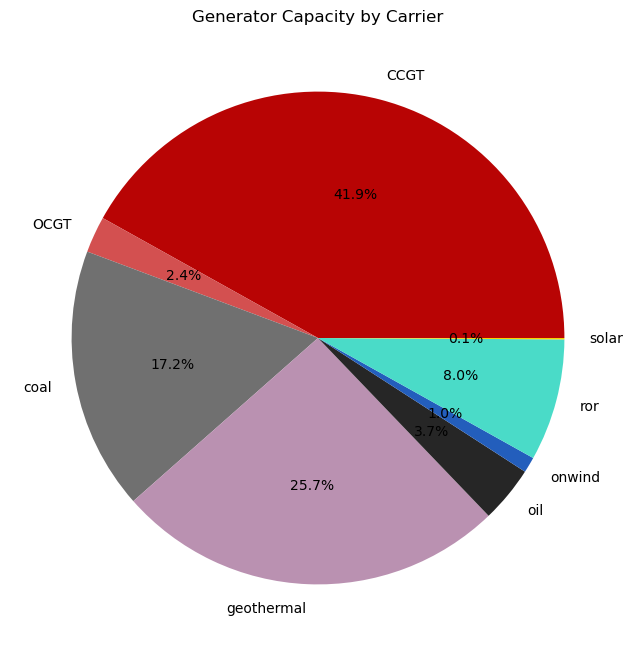

In [97]:
generator_capacity_by_carrier = (
    n.generators[n.generators.carrier != "load"]
    .groupby(["carrier"])
    .p_nom.sum()
)
plt.figure(figsize=(8, 8))
plt.pie(
    generator_capacity_by_carrier,
    labels=generator_capacity_by_carrier.index,
    autopct='%1.1f%%',
    colors=n.carriers[
            n.carriers.index.isin(generator_capacity_by_carrier.index)
        ].color.reindex(generator_capacity_by_carrier.index)
)
plt.title("Generator Capacity by Carrier")

Analyse the current gernation capacity of the energy system - tabular view

In [98]:
generator_capacity_by_carrier/1e3 # in GW

carrier
CCGT          1.752611
OCGT          0.100000
coal          0.720000
geothermal    1.073000
oil           0.154800
onwind        0.043000
ror           0.334880
solar         0.003800
Name: p_nom, dtype: float64

Analyse the future capacity of the energy system - map view

/home/vse23/anaconda3/envs/pypsa-earth/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


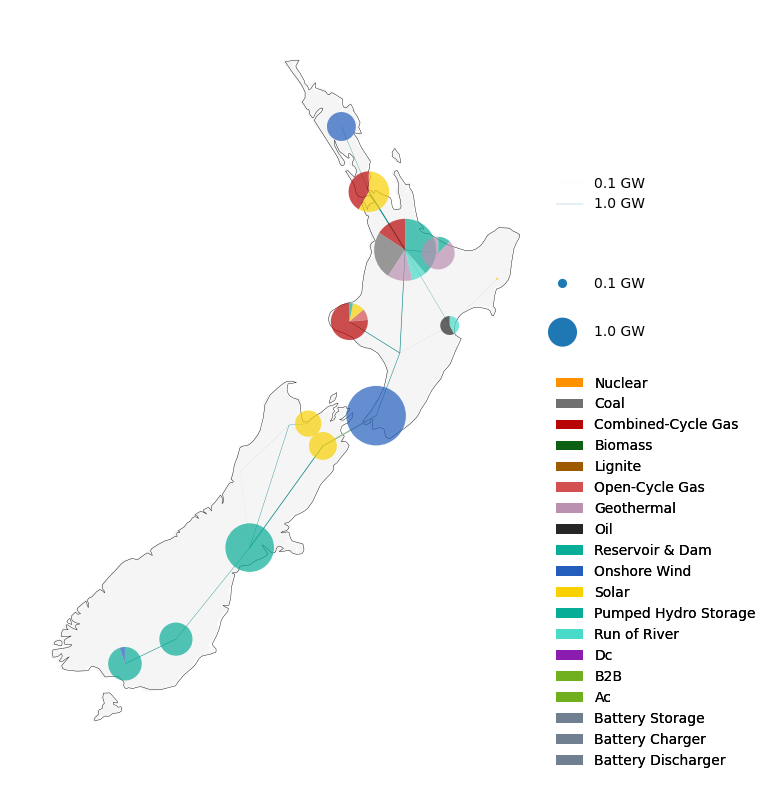

In [99]:
# Fixed NZ extent: a tight crop around the country to avoid showing the whole planet
nz_extent = [166.0, 179.0, -48.5, -33.5]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": ccrs.EqualEarth(174.0)})
gen = n.generators[n.generators.carrier != "load"].groupby(["bus", "carrier"]).p_nom_opt.sum()
sto = n.storage_units.groupby(["bus", "carrier"]).p_nom_opt.sum()
buses = pd.concat([gen, sto])

with plt.rc_context({"patch.linewidth": 0.}):
    n.plot(
        bus_sizes=buses / bus_scale,
        bus_alpha=0.7,
        line_widths=n.lines.s_nom_opt / line_scale,
        link_widths=n.links.p_nom_opt / line_scale,
        line_colors="teal",
        ax=ax,
        margin=0.02,
        color_geomap=None,
    )
regions_onshore.plot(
    ax=ax,
    facecolor="whitesmoke",
    edgecolor="white",
    aspect="equal",
    transform=ccrs.PlateCarree(),
    linewidth=0,
)
ax.set_extent(nz_extent, crs=ccrs.PlateCarree())
legend_kwargs = {"loc": "upper left", "frameon": False}
legend_circles_dict = {"bbox_to_anchor": (1, 0.67), "labelspacing": 2.5, **legend_kwargs}

add_legend_circles(
    ax,
    [s / bus_scale for s in bus_sizes],
    [f"{s / 1000} GW" for s in bus_sizes],
    legend_kw=legend_circles_dict,
)
add_legend_lines(
    ax,
    [s / line_scale for s in line_sizes],
    [f"{s / 1000} GW" for s in line_sizes],
    legend_kw={"bbox_to_anchor": (1, 0.8), **legend_kwargs},
)
add_legend_patches(
    ax,
    n.carriers.color,
    n.carriers.nice_name,
    legend_kw={"bbox_to_anchor": (1, 0), **legend_kwargs, "loc": "lower left"},
)
fig.tight_layout()

Analys the future generation capacity expansion of the energy system - bar chart

<AxesSubplot:title={'center':'Generator capacity expansion in GW'}, xlabel='carrier'>

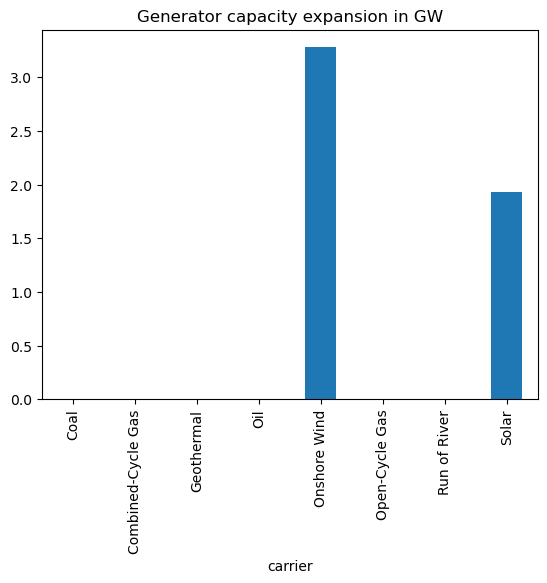

In [100]:
optimal_capacity = n.statistics.optimal_capacity(comps=["Generator"]).droplevel(0).div(1e3)
installed_capacity = n.statistics.installed_capacity(comps=["Generator"]).droplevel(0).div(1e3)
generation_capacity_expansion = optimal_capacity - installed_capacity
#generation_capacity_expansion.drop(["load"], inplace=True)
generation_capacity_expansion.plot.bar(title="Generator capacity expansion in GW")

Plot the future generation capacity expansion of the energy system - tabular chart

In [101]:
generation_capacity_expansion # In GW

carrier
Coal                  0.000000
Combined-Cycle Gas    0.000000
Geothermal            0.000000
Oil                   0.000000
Onshore Wind          3.278862
Open-Cycle Gas        0.000000
Run of River          0.000000
Solar                 1.932439
dtype: float64

Analyse the future energy generation of the energy system - bar chart view

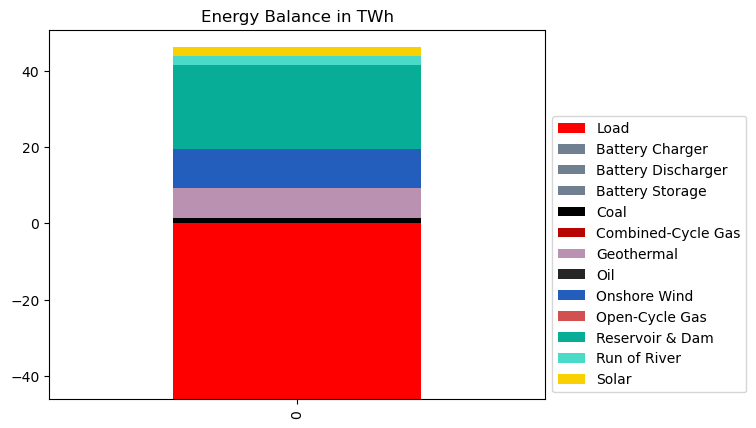

In [102]:
colors = {key.lower(): value.lower() for key, value in config["plotting"]["tech_colors"].items()}
nice_names = {value.lower(): key for key, value in config["plotting"]["nice_names"].items()}

rename_cols = {
    '-': 'Load',
    'load': 'load shedding',
}

energy_balance = (
    n.statistics.energy_balance()
    .loc[:, :, "AC"]
    .groupby("carrier")
    .sum()
    .div(1e6)
    .to_frame()
    .T
    .rename(columns=rename_cols)
)

# color-matching
color_list = []
for col in energy_balance.columns:
    original_name = col.lower()
    key_name = nice_names.get(original_name, original_name)
    color = colors.get(key_name.lower(), 'gray')
    color_list.append(color)


fig, ax = plt.subplots()
energy_balance.plot.bar(stacked=True, ax=ax, title="Energy Balance in TWh", color=color_list)
handles, labels = ax.get_legend_handles_labels()
nice_labels = [config["plotting"]["nice_names"].get(label, label) for label in energy_balance.columns]
ax.legend(handles, nice_labels, bbox_to_anchor=(1, 0), loc="lower left", title=None, ncol=1)

plt.show()

Analyse the future energy generation of the energy system - tabular view

In [103]:
n.statistics.energy_balance()/1e6 # In TWh

component    carrier             bus_carrier
Link         Battery Charger     AC            -1.505012e-05
                                 battery        1.474605e-05
             Battery Discharger  AC             1.444812e-05
                                 battery       -1.474605e-05
Generator    Coal                AC             1.526248e+00
             Combined-Cycle Gas  AC             8.638880e-03
             Geothermal          AC             7.834317e+00
             Oil                 AC             1.188751e-08
             Onshore Wind        AC             1.029384e+01
             Open-Cycle Gas      AC             4.068836e-08
             Run of River        AC             2.178621e+00
             Solar               AC             2.381835e+00
StorageUnit  Battery Storage     AC            -2.781985e-07
             Reservoir & Dam     AC             2.201458e+01
Store        Battery Storage     battery        9.716772e-13
Load         -                   AC     

## Analyse pv and wind potential - map view

In [104]:
solar = xr.open_dataset(solar_path)
wind = xr.open_dataset(onwind_path)

def plot_voronoi(n, carrier, voronoi, cmap, projection, title=None, filename=None):
    g = n.generators.loc[n.generators.carrier == carrier]
    br = gpd.read_file(f"{PARENT}resources/{scenario_name}/bus_regions/regions_{voronoi}.geojson").set_index("name")
    br_area = br.to_crs("ESRI:54009")
    br_area = br_area.geometry.area * 1e-6
    br["p_nom_max"] = g.groupby("bus").sum().p_nom_max / br_area

    fig, ax = plt.subplots(figsize=(8, 4), subplot_kw={"projection": projection})
    plt.rcParams.update({"font.size": 10})
    br.plot(
        ax=ax,
        column="p_nom_max",
        transform=ccrs.PlateCarree(),
        linewidth=0.25,
        edgecolor="k",
        cmap=cmap,
        vmin=0,
        vmax=br["p_nom_max"].max(),
        legend=True,
        legend_kwds={"label": r"potential density"},
    )
    ax.coastlines()
    ax.add_feature(cartopy.feature.BORDERS.with_scale("110m"))
    ax.set_extent(country_coordinates, crs=ccrs.PlateCarree()) 
    
    if title is not None:
        plt.title(title)

Plot wind energy potential

INFO:pypsa.io:Imported network elec.nc has buses, carriers, generators, lines, links, loads, storage_units, transformers


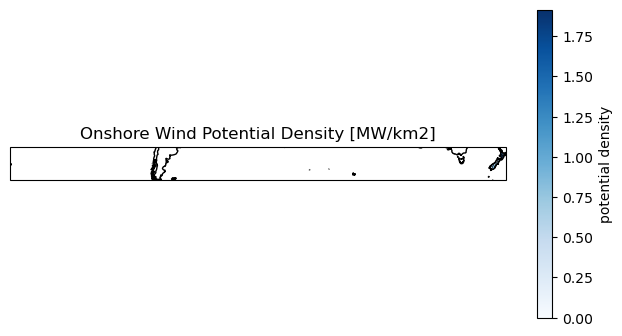

In [105]:
warnings.simplefilter(action='ignore', category=FutureWarning)
plot_voronoi(
    pypsa.Network(network_path),
    "onwind",
    "onshore",
    "Blues",
    ccrs.PlateCarree(),
    title="Onshore Wind Potential Density [MW/km2]",
)
warnings.simplefilter(action='default', category=FutureWarning)

Plot pv energy potential

INFO:pypsa.io:Imported network elec.nc has buses, carriers, generators, lines, links, loads, storage_units, transformers


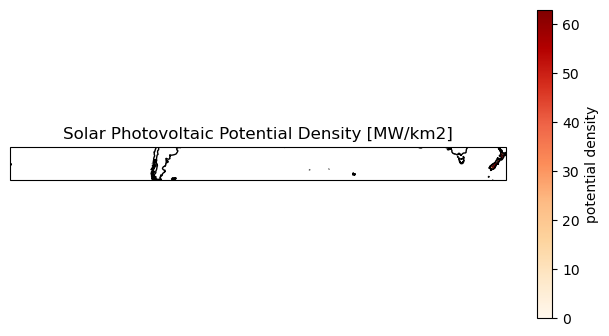

In [106]:
warnings.simplefilter(action='ignore', category=FutureWarning)
plot_voronoi(
    pypsa.Network(network_path),
    "solar",
    "onshore",
    "OrRd",
    ccrs.PlateCarree(),
    title="Solar Photovoltaic Potential Density [MW/km2]",
)
warnings.simplefilter(action='default', category=FutureWarning)